# 🌌 Linear regression!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside **problem.ipynb** and **linear_models.py**.
- Answer the follow-up questions in markdown format within this notebook. A few sentences is enough, no requirements for length of answers.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Submit **problem.ipynb** and **linear_models.py** to Canvas. Deliever the notebook such that outputs are saved, ideally *restart* the kernel followed by *run all*.

Good luck!

---

## 🔋 Problem 1: Predicting power consumption

### ❗️ The problem

You must develop a predictive model to estimate **power consumption** based on **network activity**.
️
Use `LinearRegression` class from `linear_models.py` stored in this folder. Your task is to complete two functions: `fit` (find the optimal parameters of the regression) and `predict` (apply them to the test data).

### 📋 Formal requirements
1. **Implementation**: 
   - Use standard Python libraries (numpy, math, pandas, etc.)
   - Implement `LinearRegression` class from `linear_models.py` from scratch
   - Optimize weights and bias with gradient descent from scratch

2. **Discussion**:
   - Visualize the training loss curve. Is it stable?
   - Visualize the fitted curve and derive the resulting Energy consumption formula.
   - Analyze the prediction error distribution. What is an unbiased estimator?
   - What does it tell you when the gradient in SGD is close to zero?

In [2]:
# The `%autoreload` IPython magic command allows instant updates from `linear_models.py`.
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from linear_models import LinearRegression, LogisticRegression  # <--- You will implement this

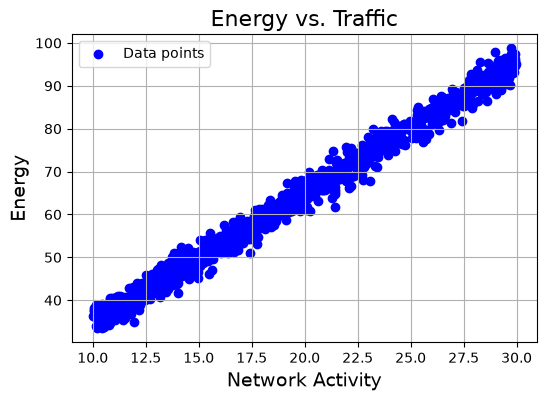

In [4]:
# Load data
data = pd.read_csv('regression.csv')

# Plot the data
plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.legend()
plt.show()

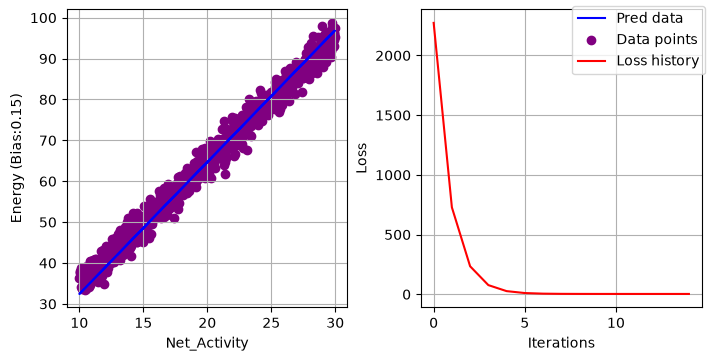

In [9]:
# ====================================

model = LinearRegression(lr=0.001, n_iterations=15)

model.fit(data["Net_Activity"], data["Energy"])

predicted_data = model.predict(data["Net_Activity"])

iterations = np.arange(model.n_iterations)


fig, ax = plt.subplots(1,2, figsize=(7,3.5),layout="constrained")
ax[0].plot(data["Net_Activity"], predicted_data, label="Pred data", color="b")
ax[0].scatter(data["Net_Activity"], data["Energy"], c="purple", label="Data points")
ax[0].set_xlabel("Net_Activity")
ax[0].set_ylabel(f"Energy (Bias:{round(model.bias,2)})")
ax[0].grid()

ax[1].plot(iterations, model.loss_history, label="Loss history", color="r")
ax[1].set_xlabel("Iterations")
ax[1].set_ylabel("Loss")
ax[1].grid()

fig.legend()
plt.savefig("Project1_task_1,png")

plt.show()

# ====================================

### ❓ Is the training loss curve stable?
       
       So stable, after about 5 iterations it bottoms out at 0.

### ❓ Derive the resulting energy consumption formula

       We get around f(x) = 3x + 0.15, where x is the Net_Activity.

### ❓ Analyze prediction error distribution. What is an unbiased estimator?
       
       An unbiased estimator $\theta^{^}$ will for all values $\theta$ have zero bias, or that it will always match the real target. To have your model be a perfect unbiased estimator would mean it always gives the right answer.

       

### ❓ What does it tell you when the gradient in SGD is close to zero?

       When the gradient in SDG is close to zero, the weight is getting very close beeing the optimal value for the given training data.

## 🔋 Problem 2: Logistic regression

### Your task
1. Implement logistic regression
2. Train your model on binary classification data
3. Engineer features to improve the model's performance

### Formal requirements
1. **Implementation**:
   - Same as before, use standard libraries
   - Implement gradient descent

2. **Performance**: Achieve at least **0.88** classification accuracy on the test set

3. **Discussion**:
   - Explain poor initial performance and your improvements
   - What is the model's inductive bias. Why is it important?
   - Plot the ROC curve, what does the area under the curve measure?

In [53]:
data = pd.read_csv('classification.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

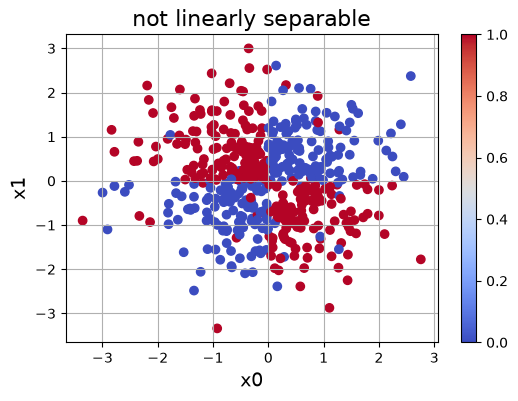

In [54]:
# visualize x0 and x1 of train on scatterplot with colors corresponding to y
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('not linearly separable', fontsize=16)
plt.colorbar()
plt.show()

AUC VALUE: 0.9350438167865555


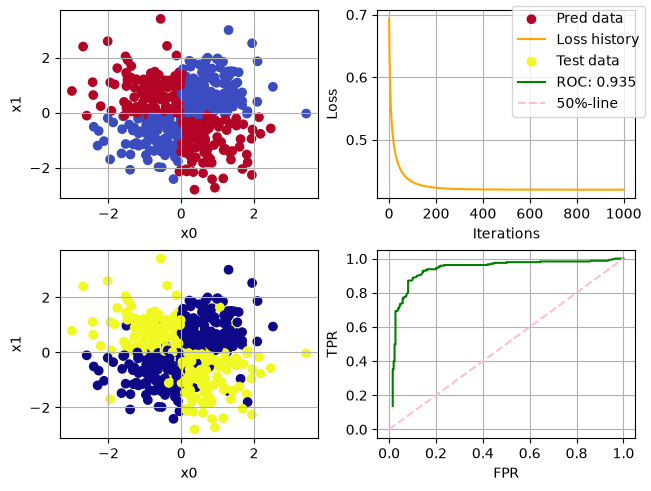

In [134]:
# ====================================
from sklearn.metrics import auc

logReg = LogisticRegression()

X_train = np.array([train['x0'],train['x1']])
y_train = np.array(train['y'])

X_test = np.array([test['x0'], test['x1']])
y_test = np.array([test['y']])

logReg.fit(X_train, y_train)

pred_data, y_pred = logReg.predict(X_test)

fig, ax = plt.subplots(2,2, layout="constrained")

ax[0,0].scatter(X_test[0], X_test[1], c=pred_data, cmap='coolwarm', label="Pred data")
ax[0,0].set_xlabel('x0')
ax[0,0].set_ylabel('x1')
ax[0,0].grid()

ax[1,0].scatter(X_test[0], X_test[1], c=y_test, cmap='plasma', label="Test data")
ax[1,0].set_xlabel('x0')
ax[1,0].set_ylabel('x1')
ax[1,0].grid()

n = np.arange(logReg.n_iterations)

ax[0,1].plot(n, logReg.loss_history, color="orange", label="Loss history")
ax[0,1].set_xlabel("Iterations")
ax[0,1].set_ylabel("Loss")
ax[0,1].grid()


def TPR_FPR_func(y_pred, y_test):
    TPR = []
    FPR = []
    for k in np.linspace(0.001,0.999,1000):
        classified = np.array([1 if _y > k else 0 for _y in y_pred])

        true_positives  = np.sum((y_test.astype(int) == 1) & (classified.astype(int) == 1))
        false_negatives = np.sum((y_test.astype(int) == 1) & (classified.astype(int) == 0))
        TPR_k = true_positives / (true_positives + false_negatives)
        
        true_negatives = np.sum((y_test.astype(int) == 0) & (classified.astype(int) == 0))
        false_positives = np.sum((y_test.astype(int) == 0) & (classified.astype(int) == 1)) 
        FPR_k = false_positives / (true_negatives + false_positives)
        

        TPR.append(TPR_k)
        FPR.append(FPR_k)
    return np.array(TPR), np.array(FPR)



TPR, FPR = TPR_FPR_func(y_pred, y_test)
print(f"AUC VALUE: {auc(FPR, TPR)}")

ax[1,1].plot(FPR, TPR, color="green", label=f"ROC: {round(auc(FPR, TPR),3)}")
ax[1,1].plot(np.linspace(0,1,1000), np.linspace(0, 1, 1000), "--", color="pink", label="50%-line")
ax[1,1].set_xlabel("FPR")
ax[1,1].set_ylabel("TPR")
ax[1,1].grid()
fig.legend()
plt.savefig("Project1_task_2.png")
plt.show()



# Best AUC VALUE: 0.8258943590893798
#                 0.8322946538714173
#                 0.8529614380236787
#                 0.8657540172062994
#                 0.9350438167865555 !!!!
 # ====================================

### ❓ Explain poor initial performance and your improvements
        The initial performance with only the two features X[0] and X[1] were pretty bad, but by adding more features to the linear regression function and calculating more classification thresholds for the AUC, I managed to get ROC up to 0.935!

### ❓ What is the model's inductive bias? Why is it important?
        The model's inductive bias is that the sign of the product of the two features x_0 and x_1 determines wether the target should be classified as 0 or 1. This is important because we can then create more features like multiplying the two together in order to get a better linear regression function. 

### ❓ What does the area under the ROC curve measure?
        The area under the ROC curve measures the likelihood that the model gives out a higher value for a random chosen positive datapoint, compared to for a random chosen negative datapoint. This can be understood from plotting the TPR against the FPR for different classification thresholds.



# NB!
## I have collaborated with Brage Losnesgård Hansen on this project! Alot of our code is similar due to alot of time spent debugging eachothers code when one works but not the other, but we both have written everything ourselves!